# Baseline correction: test, compare and document

**1KB163 — pilot workshop, 6 October 2026**

Based on [NIRPY Research: Two methods for baseline correction of spectral data](https://nirpyresearch.com/two-methods-baseline-correction-spectral-data/).

**Question:** Which baseline estimate preserves useful analytical information, and what evidence supports your choice?

We compare wavelet decomposition, asymmetric least squares (AsLS, called ALS in the article), and asymmetrically reweighted penalized least squares (arPLS). Raman and XRF are used when the original data is available. A clearly labelled synthetic spectrum adds a known baseline for quantitative evaluation.

You will inspect source metadata, apply preprocessing, explore settings, evaluate distortion, and export a documented result. This supports course outcomes 1, 2, 3, 5 and 6. Read `README.md` for setup. Run sections in order; before sharing, restart the kernel and run all.

## 1. Setup and provenance

Imports and paths are defined once. No download happens here. The notebook searches upward from its working directory for this project, so it works when launched from the project root or `notebooks/`.

In [1]:
from pathlib import Path
from importlib.metadata import version
from datetime import datetime, timezone
import json
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src' / 'baseline.py').is_file() and (p / 'notebooks' / 'baseline_workshop.ipynb').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this project folder in VS Code before running the notebook.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.baseline import (read_rruff, read_xrf, synthetic_spectrum,
                          estimate_baseline, validate_spectrum, sha256_file)

VERSIONS = {name: version(name) for name in ['numpy', 'scipy', 'pandas', 'matplotlib', 'PyWavelets', 'pybaselines', 'openpyxl']}
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True,
                     'grid.alpha': 0.2, 'font.size': 11})
METHODS = ('Wavelet', 'AsLS', 'arPLS')
COLOURS = {'Wavelet': '#0072B2', 'AsLS': '#D55E00', 'arPLS': '#009E73'}
print('Python:', platform.python_version())
display(pd.Series(VERSIONS, name='Package version').to_frame())

Python: 3.12.0


,Package version
numpy,2.5.3
scipy,1.18.1
pandas,3.0.6
matplotlib,3.11.2
PyWavelets,1.10.0
pybaselines,1.2.1
openpyxl,3.1.5


## 2. Edit parameters here

Change one setting at a time and rerun from this cell onward. Start with the tutorial's `db6`, level 7, lambda $10^6$ and AsLS $p=0.1$. Larger lambda penalizes curvature more strongly. For positive peaks, AsLS assigns weight $p$ above the baseline and $1-p$ below it; small $p$ reduces peaks' influence on the baseline fit.

The article's `niter` argument does not match its appendix's `itermax`. This adaptation uses [pybaselines](https://pybaselines.readthedocs.io/en/stable/) with `max_iter` and a convergence tolerance. It is not an exact reproduction of the article's five-iteration results. Wavelet boundary handling is symmetric; reconstruction is trimmed to the original length.

**Predict:** How might an excessively flexible baseline affect a broad peak? How might a very rigid baseline affect a curved background?

In [2]:
PARAMETERS = dict(lam=1e6, p=0.1, max_iter=50, tol=1e-3, wavelet='db6', level=7)
LAMBDA_VALUES = (1e4, 1e6, 1e8)
WAVELET_LEVELS = (5, 7)
SYNTHETIC_SEED = 163
PEAK_WINDOW = (160, 280)  # synthetic axis units; chosen to surround the first peak
RUN_LABEL = 'pilot-01'  # change to preserve each exported parameter experiment
RAMAN_FILE = 'Beryl__R110118__Broad_Scan__780__0__unoriented__Raman_Data_RAW__22217.rruff'
XRF_FILE = 'Raw data-ancient inks_16Ene2021.xlsx'

## 3. Load and inspect inputs

The original Raman URL returned HTTP 404 during preparation. Missing files are displayed in the status table. Download the original files using `data/README.md` and rerun; a missing spectrum is never replaced with synthetic data. Incorrect or nonuniform input axes raise an error that must be investigated.

**Inspect:** source/sample identity, axis units, intensity units, acquisition conditions, number of points, sampling interval, and missing values. For XRF, confirm that offset/increment rows and counts really match the selected workbook spectrum before interpreting energies.

In [3]:
spectra = {}
input_records = []
status = []
for key, filename, loader, xlabel, ylabel in [
    ('Raman', RAMAN_FILE, read_rruff, 'Raman shift (cm⁻¹)', 'Intensity (a.u.; confirm source scale)'),
    ('XRF', XRF_FILE, read_xrf, 'Energy (keV; confirm calibration)', 'Intensity (counts)'),
]:
    path = ROOT / 'data' / 'raw' / filename
    if path.is_file():
        x, y, metadata = loader(path)
        spectra[key] = dict(x=x, y=y, xlabel=xlabel, ylabel=ylabel, metadata=metadata)
        input_records.append(dict(dataset=key, file=str(path.relative_to(ROOT)),
                                  sha256=sha256_file(path), import_metadata=metadata))
        status.append(dict(dataset=key, status='Loaded; inspect metadata', points=len(x)))
        print(f'{key} metadata:')
        print(json.dumps(metadata, indent=2))
    else:
        status.append(dict(dataset=key, status='MISSING — see data/README.md', points=0))

x, y, true_baseline, true_peaks = synthetic_spectrum(SYNTHETIC_SEED)
validate_spectrum(x, y)
spectra['Synthetic'] = dict(x=x, y=y, xlabel='Synthetic axis (a.u.)', ylabel='Synthetic intensity (a.u.)',
                           true_baseline=true_baseline, true_peaks=true_peaks,
                           metadata={'seed': SYNTHETIC_SEED, 'points': len(x), 'noise_sd': 0.8})
status.append(dict(dataset='Synthetic', status='Generated — known baseline, not real data', points=len(x)))
display(pd.DataFrame(status))
display(pd.DataFrame([dict(dataset=k, points=len(s['x']), axis_min=s['x'].min(), axis_max=s['x'].max(),
                          median_step=np.median(np.diff(s['x'])), intensity_min=s['y'].min(), intensity_max=s['y'].max())
                      for k, s in spectra.items()]))

,dataset,status,points
0,Raman,MISSING — see data/README.md,0
1,XRF,MISSING — see data/README.md,0
2,Synthetic,"Generated — known baseline, not real data",2048


,dataset,points,axis_min,axis_max,median_step,intensity_min,intensity_max
0,Synthetic,2048,0.0,1000.0,0.48852,21.667362,115.496643


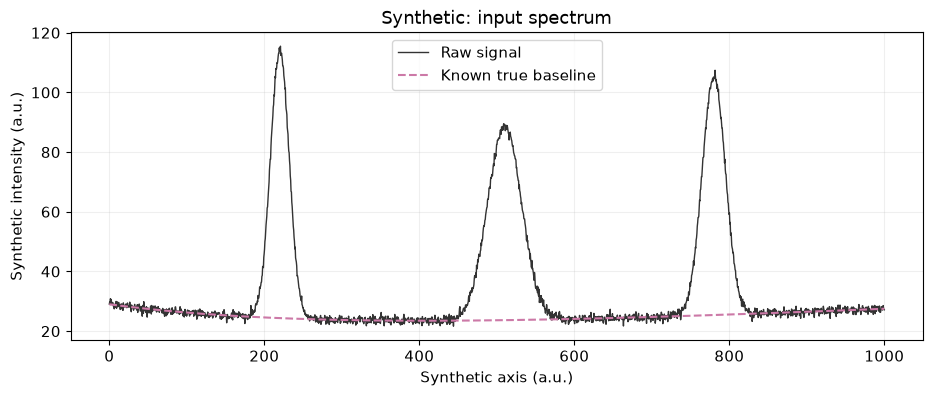

In [4]:
for name, spectrum in spectra.items():
    fig, ax = plt.subplots()
    ax.plot(spectrum['x'], spectrum['y'], color='#333333', linewidth=1, label='Raw signal')
    if name == 'Synthetic':
        ax.plot(spectrum['x'], spectrum['true_baseline'], '--', color='#CC79A7', label='Known true baseline')
    ax.set(xlabel=spectrum['xlabel'], ylabel=spectrum['ylabel'], title=f'{name}: input spectrum')
    ax.legend()
    plt.show()
    plt.close(fig)

## 4. Estimate, subtract and compare

Each method returns a baseline $b$; the corrected signal is $y-b$. The wavelet approach removes the coarsest approximation, which can contain broad analytical features as well as background. The penalized methods balance smoothness and asymmetric weights. Neither guarantees preservation of every peak.

Plot raw signal with baseline estimates above, corrected signals below. Look near broad peaks and both edges. A few negative values can be consistent with noise; a flat or nonnegative result alone is not a quality criterion. Convergence reports a numerical stopping condition, not chemical validity.

In [5]:
results = {}
diagnostics = []
for name, spectrum in spectra.items():
    results[name] = {}
    for method in METHODS:
        baseline, info = estimate_baseline(spectrum['y'], method, **PARAMETERS)
        corrected = spectrum['y'] - baseline
        if baseline.shape != spectrum['y'].shape or not np.isfinite(baseline).all():
            raise RuntimeError(f'Invalid {method} baseline for {name}')
        results[name][method] = dict(baseline=baseline, corrected=corrected, diagnostics=info)
        diagnostics.append(dict(dataset=name, method=method, converged=info.get('converged', 'N/A'),
                                iterations=info.get('iterations_reported', 'N/A'),
                                negative_fraction=float(np.mean(corrected < 0))))
display(pd.DataFrame(diagnostics))

,dataset,method,converged,iterations,negative_fraction
0,Synthetic,Wavelet,N/A,N/A,0.520996
1,Synthetic,AsLS,True,5,0.234375
2,Synthetic,arPLS,True,16,0.349121


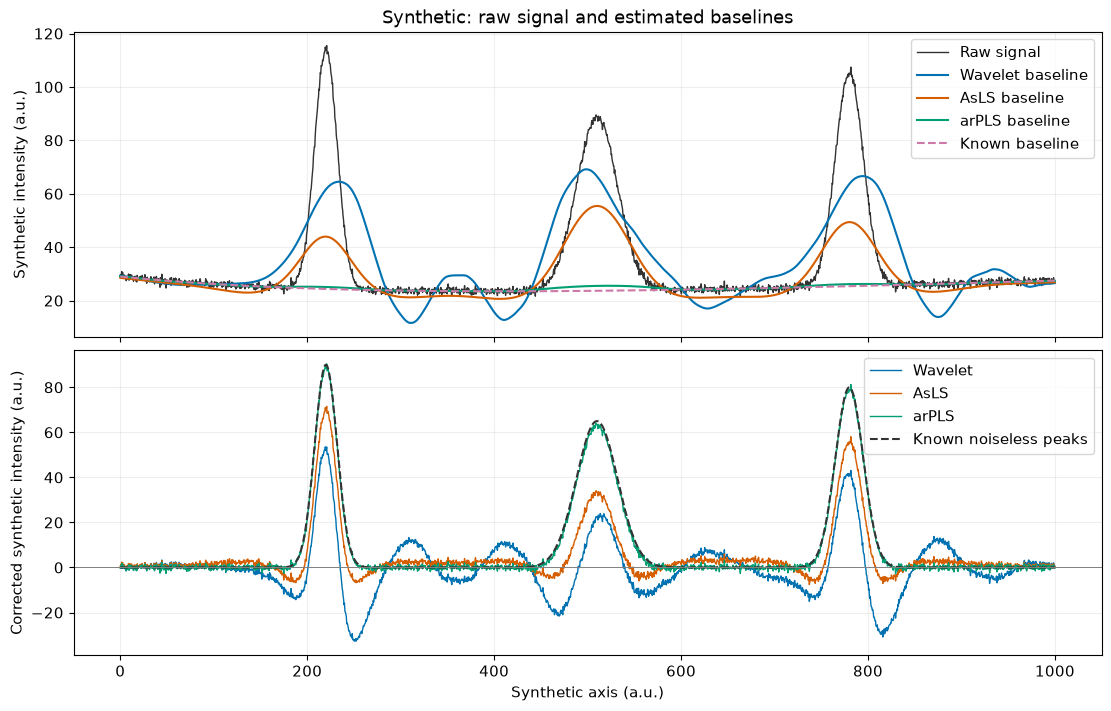

In [6]:
comparison_figures = {}
for name, spectrum in spectra.items():
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
    axes[0].plot(spectrum['x'], spectrum['y'], color='#333333', linewidth=1, label='Raw signal')
    for method, result in results[name].items():
        axes[0].plot(spectrum['x'], result['baseline'], color=COLOURS[method], label=f'{method} baseline')
        axes[1].plot(spectrum['x'], result['corrected'], color=COLOURS[method], linewidth=1, label=method)
    if name == 'Synthetic':
        axes[0].plot(spectrum['x'], spectrum['true_baseline'], '--', color='#CC79A7', label='Known baseline')
        axes[1].plot(spectrum['x'], spectrum['true_peaks'], '--', color='#333333', label='Known noiseless peaks')
    axes[0].set(title=f'{name}: raw signal and estimated baselines', ylabel=spectrum['ylabel'])
    axes[1].axhline(0, color='gray', linewidth=0.7)
    axes[1].set(xlabel=spectrum['xlabel'], ylabel='Corrected ' + spectrum['ylabel'].lower())
    for ax in axes:
        ax.legend(loc='upper right')
    comparison_figures[name] = fig
    plt.show()
    plt.close(fig)

## 5. Quantify performance where truth is known

For the synthetic spectrum only, calculate baseline RMSE and error in the integrated signal over a fixed peak window. The reference area is the noiseless peak signal integrated over the same finite window. The corrected signal retains measurement noise; these errors reflect both noise and baseline estimation. Peak-window area is not the full area of an infinite Gaussian.

**Discuss:** Does the method with the lowest baseline RMSE also give the lowest absolute area error? Why can these criteria disagree? On Raman/XRF, what independent evidence would you need to make an equivalent accuracy claim?

In [7]:
synthetic = spectra['Synthetic']
mask = (synthetic['x'] >= PEAK_WINDOW[0]) & (synthetic['x'] <= PEAK_WINDOW[1])
if mask.sum() < 2:
    raise ValueError('Peak window must contain at least two synthetic points.')
reference_area = float(np.trapezoid(synthetic['true_peaks'][mask], synthetic['x'][mask]))
if reference_area <= 0:
    raise ValueError('Choose a window containing a synthetic peak.')
def evaluate_synthetic(baseline):
    corrected = synthetic['y'] - baseline
    area = float(np.trapezoid(corrected[mask], synthetic['x'][mask]))
    return dict(baseline_rmse=float(np.sqrt(np.mean((baseline - synthetic['true_baseline']) ** 2))),
                peak_window_area=area, reference_area=reference_area,
                area_error_percent=100 * (area - reference_area) / reference_area)
quality = pd.DataFrame([dict(method=method, **evaluate_synthetic(result['baseline']))
                        for method, result in results['Synthetic'].items()])
display(quality.round(3))

,method,baseline_rmse,peak_window_area,reference_area,area_error_percent
0,Wavelet,18.361,-240.497,2707.157,-108.884
1,AsLS,10.229,1536.029,2707.157,-43.260
2,arPLS,0.614,2648.144,2707.157,-2.180


## 6. Parameter experiment

Keep the data and noise seed fixed. Explore lambda for AsLS/arPLS and decomposition level for wavelets. Record the numerical and analytical consequences separately. Index-based smoothness penalties depend on sample spacing/point count; the same lambda should not be assumed optimal for every spectrum.

**Task:** Choose settings using both baseline and peak-window criteria. Then inspect their effect on a real spectrum. Explain what the synthetic experiment can and cannot establish.

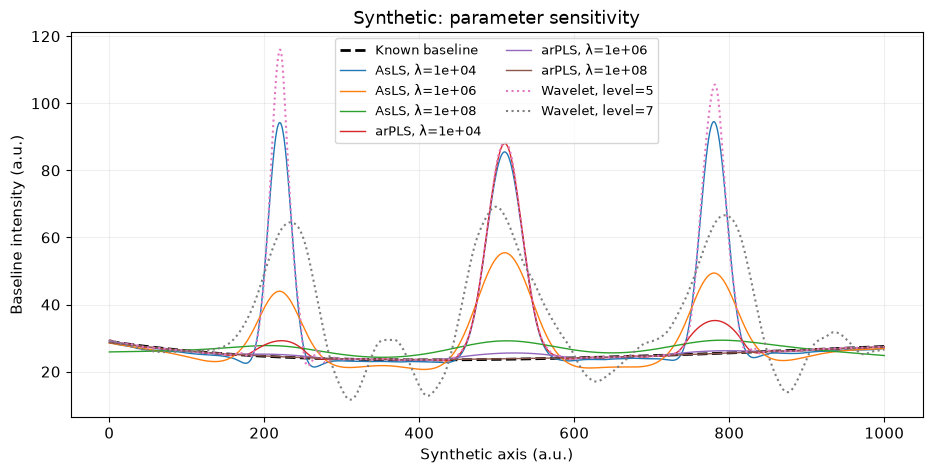

,method,lam,level,converged,baseline_rmse,peak_window_area,reference_area,area_error_percent
0,AsLS,10000.0,NaN,True,20.426,420.814,2707.157,-84.455
1,AsLS,1000000.0,NaN,True,10.229,1536.029,2707.157,-43.260
2,AsLS,100000000.0,NaN,True,2.661,2365.722,2707.157,-12.612
3,arPLS,10000.0,NaN,True,12.982,2438.014,2707.157,-9.942
4,arPLS,1000000.0,NaN,True,0.614,2648.144,2707.157,-2.180
5,arPLS,100000000.0,NaN,True,0.091,2695.875,2707.157,-0.417
6,Wavelet,NaN,5.0,N/A,22.467,-0.135,2707.157,-100.005
7,Wavelet,NaN,7.0,N/A,18.361,-240.497,2707.157,-108.884


In [8]:
sensitivity_rows = []
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(synthetic['x'], synthetic['true_baseline'], '--', color='black', linewidth=2, label='Known baseline')
for method in ('AsLS', 'arPLS'):
    for lam in LAMBDA_VALUES:
        settings = {**PARAMETERS, 'lam': lam}
        baseline, info = estimate_baseline(synthetic['y'], method, **settings)
        sensitivity_rows.append(dict(method=method, lam=lam, level=None, converged=info['converged'],
                                     **evaluate_synthetic(baseline)))
        ax.plot(synthetic['x'], baseline, label=f'{method}, λ={lam:.0e}', linewidth=1)
for level in WAVELET_LEVELS:
    baseline, info = estimate_baseline(synthetic['y'], 'Wavelet', **{**PARAMETERS, 'level': level})
    sensitivity_rows.append(dict(method='Wavelet', lam=None, level=level, converged='N/A',
                                 **evaluate_synthetic(baseline)))
    ax.plot(synthetic['x'], baseline, ':', linewidth=1.5, label=f'Wavelet, level={level}')
ax.set(xlabel=synthetic['xlabel'], ylabel='Baseline intensity (a.u.)', title='Synthetic: parameter sensitivity')
ax.legend(ncol=2, fontsize=9)
plt.show()
plt.close(fig)
parameter_figure = fig
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(3))

## 7. Export a reproducible run

The next cell writes processed CSVs, comparison PNGs, metrics and JSON metadata to `outputs/<RUN_LABEL>/`. Use a new run label for a new experiment; an existing label overwrites that run's files. All raw inputs remain unchanged. The record includes input hashes, parameters, convergence histories, package versions and synthetic generation details.

For an executed notebook and HTML preview, run `scripts/render_workshop.py` as described in the README, or use VS Code's notebook export after restarting and running all.

In [9]:
if not RUN_LABEL or Path(RUN_LABEL).name != RUN_LABEL or RUN_LABEL in ('.', '..'):
    raise ValueError('RUN_LABEL must be a single folder name.')
out = ROOT / 'outputs' / RUN_LABEL
out.mkdir(parents=True, exist_ok=True)
for name, spectrum in spectra.items():
    table = pd.DataFrame({'axis': spectrum['x'], 'raw_intensity': spectrum['y']})
    for method, result in results[name].items():
        table[f'{method}_baseline'] = result['baseline']
        table[f'{method}_corrected'] = result['corrected']
    if name == 'Synthetic':
        table['true_baseline'] = spectrum['true_baseline']
        table['true_noiseless_peaks'] = spectrum['true_peaks']
    table.to_csv(out / f'{name.lower()}_processed.csv', index=False)
    comparison_figures[name].savefig(out / f'{name.lower()}_comparison.png', dpi=180, bbox_inches='tight')
quality.to_csv(out / 'synthetic_quality.csv', index=False)
sensitivity.to_csv(out / 'parameter_sensitivity.csv', index=False)
parameter_figure.savefig(out / 'parameter_sensitivity.png', dpi=180, bbox_inches='tight')
run_metadata = dict(
    created_utc=datetime.now(timezone.utc).isoformat(), run_label=RUN_LABEL,
    python=platform.python_version(), packages=VERSIONS, parameters=PARAMETERS,
    input_status=status, inputs=input_records,
    units={k: {'axis_label': s['xlabel'], 'signal_label': s['ylabel']} for k, s in spectra.items()},
    synthetic={'seed': SYNTHETIC_SEED, 'points': 2048, 'axis_range': [0, 1000],
               'baseline_equation': '15 + 0.012*x + 14*exp(-x/300)',
               'gaussian_peaks_centre_width_height': [[220, 12, 90], [510, 22, 65], [780, 15, 80]],
               'noise_distribution': 'normal(0, 0.8)', 'peak_window': list(PEAK_WINDOW)},
    sensitivity_settings={'lambda_values': list(LAMBDA_VALUES), 'wavelet_levels': list(WAVELET_LEVELS)},
    diagnostics={name: {method: value['diagnostics'] for method, value in methods.items()}
                 for name, methods in results.items()},
    tutorial_url='https://nirpyresearch.com/two-methods-baseline-correction-spectral-data/',
    adaptation='pybaselines implementation; convergence-based iterations; synthetic validation; explicit loaders')
(out / 'run_metadata.json').write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')
print('Exported run:', out)

Exported run: c:\Git_repo\1KB163\20261006_Baseline correction_NIRPY_test\outputs\pilot-01


## 8. Interpretation and reproducibility record

Edit this Markdown cell after your experiment:

- **Data/source and inspected metadata:** …
- **Chosen method and settings:** …
- **Evidence supporting the choice:** …
- **Peak/edge distortions and limitations:** …
- **What requires independent validation on real samples:** …
- **Run label, input hashes and exported result:** …
- **Can another student reproduce the result after a fresh-kernel run?** …

### Sources

- [NIRPY tutorial](https://nirpyresearch.com/two-methods-baseline-correction-spectral-data/) by Daniel Pelliccia.
- [RRUFF sample R110118](https://rruff.info/R110118).
- Zamalloa Jara et al. (2023), [Mendeley Data, version 2](https://doi.org/10.17632/228pwkw55h.2), CC BY 4.0.
- [AsLS API](https://pybaselines.readthedocs.io/en/stable/generated/api/pybaselines.Baseline.asls.html), [arPLS API](https://pybaselines.readthedocs.io/en/stable/generated/api/pybaselines.Baseline.arpls.html).

Source data and imported algorithms retain their respective attribution/terms. The LGPL appendix from the article is not copied into this project.